## Imports

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization

In [57]:
%matplotlib inline

In [58]:
print(tf.config.list_physical_devices("GPU"))

[]


## Utils

In [59]:
def plot_history(history, title="Model Performance"):
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history["accuracy"], label="train")
    ax1.plot(history.history["val_accuracy"], label="validation")
    ax1.set_title(f"{title} - Accuracy")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.legend()

    ax2.plot(history.history["loss"], label="train")
    ax2.plot(history.history["val_loss"], label="validation")
    ax2.set_title(f"{title} - Loss")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
def evaluate_model(model, X_test, y_test, title="Evaluation"):
    print(f"\n{title}:")
    y_pred_probs = model.predict(X_test)
    y_pred = (y_pred_probs > 0.5).astype(int)

    print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

## EDA

In [61]:
data = pd.read_csv("../data/creditcard.csv")

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [62]:
data.isnull().sum().max()

np.int64(0)

In [63]:
data["Amount"].value_counts().head()

Amount
1.00     13688
1.98      6044
0.89      4872
9.99      4747
15.00     3280
Name: count, dtype: int64

In [64]:
data["Class"].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

In [65]:
scaler = StandardScaler()
data["Amount"] = scaler.fit_transform(data[["Amount"]])

data = data.drop(["Time"], axis=1)

In [66]:
X = data.drop("Class", axis=1)
y = data["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=101
)

In [76]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((199364, 29), (85443, 29), (199364,), (85443,))

## Model V1 (Baseline)

In [67]:
model_v1 = Sequential()

model_v1.add(Input(shape=(X_train.shape[1],)))

model_v1.add(Dense(16, activation="relu"))
model_v1.add(Dense(8, activation="relu"))
model_v1.add(Dense(1, activation="sigmoid"))

model_v1.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_v1.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 16)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 625 (2.44 KB)

 Trainable params: 625 (2.44 KB)

 Non-trainable params: 0 (0.00 B)

In [68]:
history_v1 = model_v1.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=5,
    batch_size=256,
    verbose=1,
)

Epoch 1/5
779/779 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9715 - loss: 0.0927 - val_accuracy: 0.9994 - val_loss: 0.0045
Epoch 2/5
779/779 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9993 - loss: 0.0041 - val_accuracy: 0.9995 - val_loss: 0.0034
Epoch 3/5
779/779 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9994 - loss: 0.0035 - val_accuracy: 0.9995 - val_loss: 0.0032
Epoch 4/5
779/779 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9994 - loss: 0.0032 - val_accuracy: 0.9995 - val_loss: 0.0030
Epoch 5/5
779/779 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9994 - loss: 0.0030 - val_accuracy: 0.9995 - val_loss: 0.0028


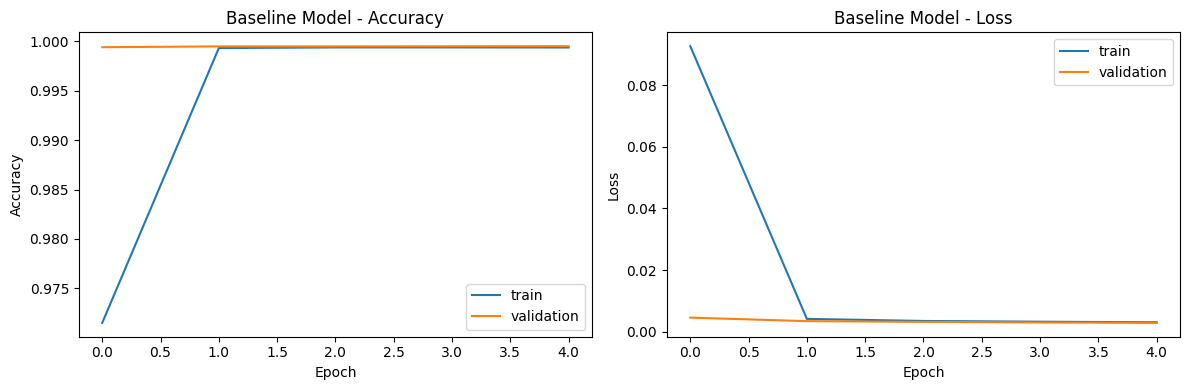


Baseline Model Results:
2671/2671 ━━━━━━━━━━━━━━━━━━━━ 2s 627us/step
Accuracy Score: 0.9995

Confusion Matrix:
[[85286    13]
 [   28   116]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85299
           1       0.90      0.81      0.85       144

    accuracy                           1.00     85443
   macro avg       0.95      0.90      0.92     85443
weighted avg       1.00      1.00      1.00     85443



In [69]:
plot_history(history_v1, title="Baseline Model")
evaluate_model(model_v1, X_test, y_test, title="Baseline Model Results")

## Model V2 (Class Weights)

In [ ]:
weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(weights))

print(f"Class Weights applied: {class_weights}")

Class Weights applied: {0: np.float64(0.5008743015636934), 1: np.float64(286.4425287356322)}


In [71]:
history_v2 = model_v1.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=5,
    batch_size=256,
    class_weight=class_weights,
    verbose=1,
)

Epoch 1/5
779/779 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9816 - loss: 0.1892 - val_accuracy: 0.9679 - val_loss: 0.1179
Epoch 2/5
779/779 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9739 - loss: 0.1243 - val_accuracy: 0.9772 - val_loss: 0.0856
Epoch 3/5
779/779 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9741 - loss: 0.1132 - val_accuracy: 0.9792 - val_loss: 0.0835
Epoch 4/5
779/779 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9780 - loss: 0.1027 - val_accuracy: 0.9823 - val_loss: 0.0738
Epoch 5/5
779/779 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9801 - loss: 0.0939 - val_accuracy: 0.9822 - val_loss: 0.0724


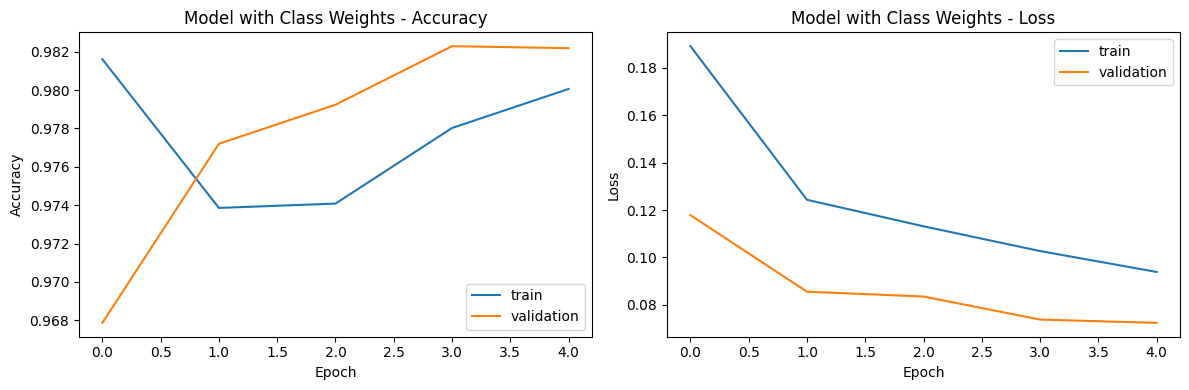


Model with Class Weights:
2671/2671 ━━━━━━━━━━━━━━━━━━━━ 2s 623us/step
Accuracy Score: 0.9822

Confusion Matrix:
[[83792  1507]
 [   15   129]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     85299
           1       0.08      0.90      0.14       144

    accuracy                           0.98     85443
   macro avg       0.54      0.94      0.57     85443
weighted avg       1.00      0.98      0.99     85443



In [72]:
plot_history(history_v2, title="Model with Class Weights")
evaluate_model(model_v1, X_test, y_test, title="Model with Class Weights")

## Model V3 (Improved Architecture)

In [73]:
model_v3 = Sequential()

model_v3.add(Input(shape=(X_train.shape[1],)))

model_v3.add(Dense(64, activation="relu"))
model_v3.add(BatchNormalization())
model_v3.add(Dropout(0.3))

model_v3.add(Dense(32, activation="relu"))
model_v3.add(BatchNormalization())
model_v3.add(Dropout(0.3))

model_v3.add(Dense(16, activation="relu"))
model_v3.add(BatchNormalization())
model_v3.add(Dropout(0.2))

model_v3.add(Dense(1, activation="sigmoid"))

model_v3.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_v3.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 64)             │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,993 (19.50 KB)

 Trainable params: 4,769 (18.63 KB)

 Non-trainable params: 224 (896.00 B)

In [ ]:
history_v3 = model_v3.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=256,
    class_weight=class_weights,
    verbose=1,
)

Epoch 1/10
779/779 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7746 - loss: 0.3919 - val_accuracy: 0.9773 - val_loss: 0.2132
Epoch 2/10
779/779 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9369 - loss: 0.2336 - val_accuracy: 0.9733 - val_loss: 0.1523
Epoch 3/10
779/779 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9529 - loss: 0.2158 - val_accuracy: 0.9781 - val_loss: 0.1247
Epoch 4/10
779/779 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9603 - loss: 0.1921 - val_accuracy: 0.9774 - val_loss: 0.1189
Epoch 5/10
779/779 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9574 - loss: 0.1791 - val_accuracy: 0.9845 - val_loss: 0.1068
Epoch 6/10
779/779 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9615 - loss: 0.1605 - val_accuracy: 0.9801 - val_loss: 0.0986
Epoch 7/10
779/779 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9647 - loss: 0.1502 - val_accuracy: 0.9821 - val_loss: 0.0897
Epoch 8/10
779/779 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9575 - loss: 0.1627 - val_accuracy: 0.

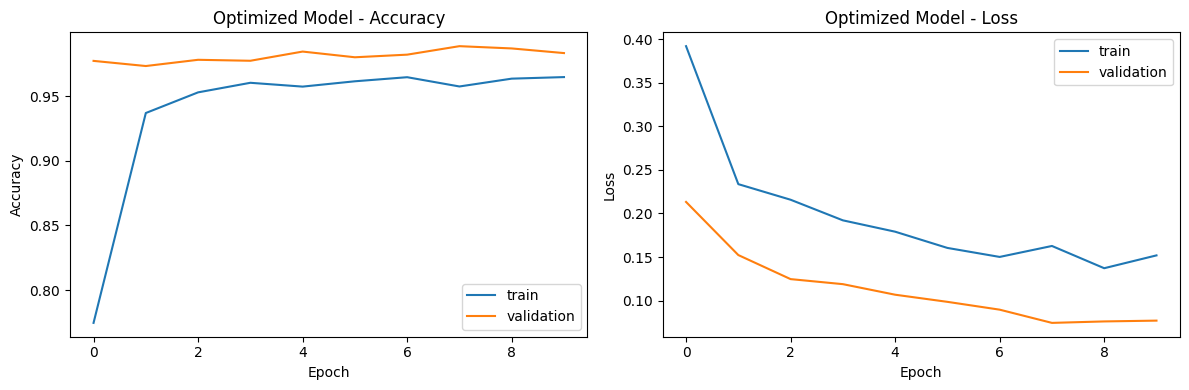


Optimized Model Results:
2671/2671 ━━━━━━━━━━━━━━━━━━━━ 2s 583us/step
Accuracy Score: 0.9833

Confusion Matrix:
[[83890  1409]
 [   16   128]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     85299
           1       0.08      0.89      0.15       144

    accuracy                           0.98     85443
   macro avg       0.54      0.94      0.57     85443
weighted avg       1.00      0.98      0.99     85443



In [75]:
plot_history(history_v3, title="Optimized Model")
evaluate_model(model_v3, X_test, y_test, title="Optimized Model Results")